In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pymcel as pc

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


El problema comienza con 2 cuerpos que se atraen gravitacionalmente.

In [2]:
# Canonical Unitsss

G = 1

r1_vec_0 = np.array([0,0,0])
v1_vec_0 = np.array([0,0,0])
m1 = 1

r2_vec_0 = np.array([1,0,0])
v2_vec_0 = np.array([0,1,0])
m2 = 1

¿Cuál es la trayectoria que siguen estas 2 partículas? Existe la solución al problema relativo

In [3]:
mu = G*(m1+m2)
r_vec_0 = r1_vec_0 - r2_vec_0
v_vec_0 = v1_vec_0 - v2_vec_0

r0 = np.linalg.norm(r_vec_0)
v0 = np.linalg.norm(v_vec_0)

In [4]:
# Problem quadratures

# MARE
h_vec = np.cross(r_vec_0,v_vec_0)
h = np.linalg.norm(h_vec)           # Ctrl shift 7 fpr commenting all selected
h_vec, r_vec_0, v_vec_0

(array([0, 0, 1]), array([-1,  0,  0]), array([ 0, -1,  0]))

In [5]:
# ERE
e_vec = np.cross(v_vec_0,h_vec)/mu - r_vec_0/r0
e = np.linalg.norm(e_vec)                          # min distance is at e_vec, e
e_vec, e

(array([0.5, 0. , 0. ]), np.float64(0.5))

In [6]:
# Energy
epsilon = v0**2/2 - mu/r0
epsilon

np.float64(-1.5)

In [7]:
e = np.sqrt(1 + 2*epsilon*h**2/mu**2)
e

np.float64(0.5)

In [8]:
p = h**2/mu
q = p/(1+e)
Q = p/(1-e)

p, q, Q

(np.float64(0.5), np.float64(0.3333333333333333), np.float64(1.0))

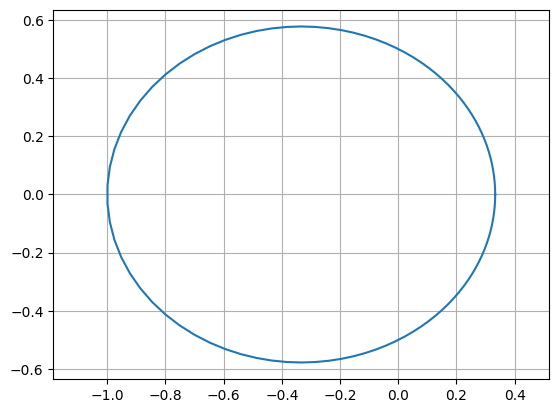

In [9]:
thetaer = np.linspace(0, 2 * np.pi, 100)
rs = p / (1 + e * np.cos(thetaer))

xfs = rs * np.cos(thetaer)
yfs = rs * np.sin(thetaer)

# Graph!! 
plt.plot(xfs, yfs)
plt.grid()
plt.axis('equal')
plt.show()

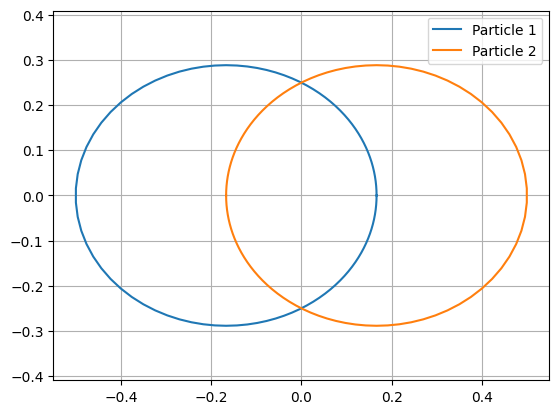

In [10]:
# Trayectory per particle

rvecs = np.array([xfs, yfs]).T

M = m1 + m2
r1vecs = m2 / M * rvecs
r2vecs = -m1 / M * rvecs


plt.plot(r1vecs[:,0], r1vecs[:,1], label='Particle 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Particle 2')
plt.grid()
plt.axis('equal')
plt.legend()
plt.show()

In [15]:
sistema = [
    dict(m=m1, r=r1_vec_0, v=v1_vec_0),
    dict(m=m2, r=r2_vec_0, v=v2_vec_0)
]

ts  = np.linspace(0, 3, 200)
rs, vs, rps, vps, cuadratura = pc.ncuerpos_solucion(sistema, ts)

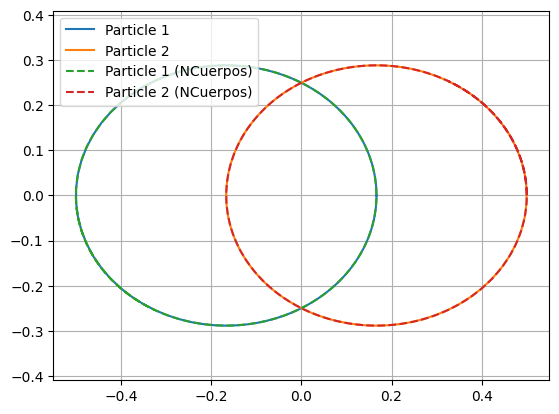

In [16]:
plt.plot(r1vecs[:,0], r1vecs[:,1], label='Particle 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Particle 2')

plt.plot(rps[0,:,0], rps[0,:,1], label='Particle 1 (NCuerpos)', linestyle='--')
plt.plot(rps[1,:,0], rps[1,:,1], label='Particle 2 (NCuerpos)', linestyle='--')
#plt.plot(r1_vec_0[0], r1_vec_0[1], 'ro', label='Initial Position 1')
#plt.plot(r2_vec_0[0], r2_vec_0[1], 'bo', label='Initial Position 2')
plt.grid()
plt.axis('equal')
plt.legend()
plt.show()